Clustering - classifying unlabelled data based on similarities


In [9]:
from sklearn.datasets import make_blobs

In [10]:
X, y = make_blobs(200, 3, centers=3, cluster_std=0.6, random_state=0)
#  len(make_blobs(200, 3, centers=3, cluster_std=0.6, random_state=0))

In [11]:
import pandas as pd
df = pd.DataFrame(X, columns = ['a', 'b', 'c'])
df.head()

,a,b,c
0,0.579608,3.595673,2.173853
1,1.488134,-2.222428,2.655960
2,-1.005970,7.211443,10.025286
3,0.062948,-1.505148,2.429239
4,0.225738,4.858938,1.512396


## K-Means 

In [12]:
from sklearn.cluster import KMeans 

In [13]:
inertias = [0, 0]

In [14]:
# n_clusters = 2
# kmeans = KMeans(n_clusters = n_clusters)
# kmeans.fit(X)


In [15]:
# inertias.append(kmeans.inertia_)

In [16]:
n_clusters = 3
kmeans = KMeans(n_clusters = n_clusters)
kmeans.fit(X)
inertias.append(kmeans.inertia_)

In [17]:
inertias

[0, 0, 203.29085284324537]

In [18]:
inertias=[]
for n_clusters in range(2, 10):
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
inertias

[1463.1655117123726,
 203.29085284324537,
 186.14133789508338,
 163.67927067421624,
 155.03217185674205,
 132.8721423204992,
 135.9289843392062,
 118.12390516031174]

In [19]:
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'Inertia')

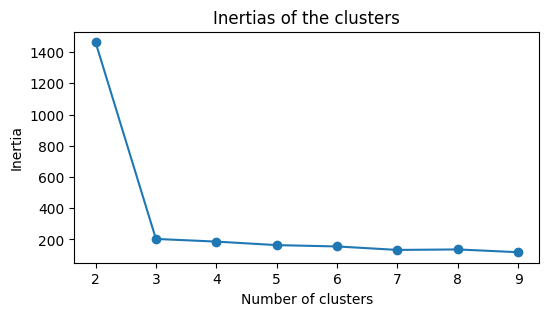

In [20]:
plt.figure(figsize=(6, 3))
plt.plot(range(2, 10),inertias, marker='o', label = 'inertia')
plt.title('Inertias of the clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
# plt.xticks(labels=np.arange(2, 10).astype(str))

In [21]:
from sklearn.metrics import silhouette_score

sil_scores=[]
for n_clusters in range(2, 10):
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(X)
    sil_scores.append(
        silhouette_score(X, kmeans.labels_)
    )

sil_scores


[np.float64(0.6962222601311916),
 np.float64(0.804222021292156),
 np.float64(0.6206411344972018),
 np.float64(0.42512219491317554),
 np.float64(0.4366958235850971),
 np.float64(0.26118048514698794),
 np.float64(0.24648066668490287),
 np.float64(0.2529678262024262)]

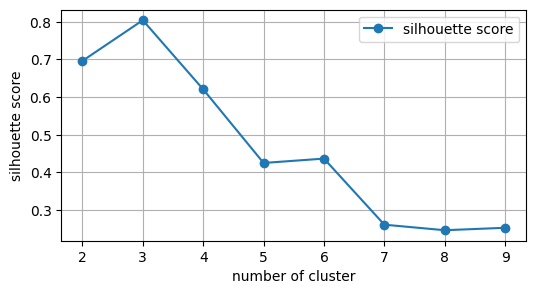

In [22]:
plt.figure(figsize=(6, 3))
plt.plot(range(2, 10), sil_scores, marker='o', label ='silhouette score')
plt.legend()
plt.xlabel('number of cluster')
plt.ylabel('silhouette score')
plt.grid()


In [23]:
kmeans = KMeans(n_clusters = 3)
kmeans.fit(X)
kmeans.labels_

array([2, 0, 1, 0, 2, 2, 1, 2, 0, 2, 2, 0, 0, 0, 1, 1, 1, 1, 0, 2, 1, 2,
       2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1,
       1, 0, 1, 1, 1, 0, 2, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 0, 1, 1, 2, 1,
       0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 2, 1, 0, 2, 1, 1, 1, 0, 0, 1, 2, 1,
       0, 0, 0, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 2, 1, 1, 1,
       1, 1, 2, 2, 1, 0, 0, 1, 1, 1, 1, 2, 1, 2, 2, 2, 0, 2, 1, 1, 0, 0,
       2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 1, 1, 0, 0, 2, 0, 0, 2, 2, 0, 1, 1,
       2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 0, 0, 2, 1,
       0, 0, 0, 1, 1, 0, 1, 2, 2, 1, 1, 0, 2, 1, 1, 0, 1, 1, 2, 1, 1, 0,
       0, 2], dtype=int32)

In [24]:
df['labels'] = kmeans.labels_
df

,a,b,c,labels
0,0.579608,3.595673,2.173853,2
1,1.488134,-2.222428,2.655960,0
2,-1.005970,7.211443,10.025286,1
3,0.062948,-1.505148,2.429239,0
4,0.225738,4.858938,1.512396,2
...,...,...,...,...
195,-1.712408,7.417851,9.025841,1
196,-1.489591,6.915651,10.201003,1
197,0.758952,-2.493050,3.776243,0
198,0.827119,-1.303032,2.686265,0


K-Means Algorithm:

1. Initialize: Randomly choose K data points as initial centroids.


2. Assign: Assign each data point to the closest centroid (usually using Euclidean distance).


3. Update: Recompute the centroids as the mean of all data points in the cluster.


4. Repeat: Steps 2 and 3 until convergence (centroids no longer change or changes fall below a threshold).

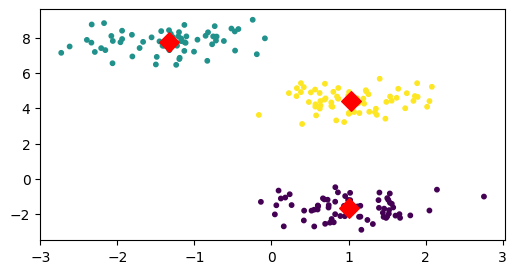

In [26]:
plt.figure(figsize=(6, 3))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, marker='o', s=10, cmap='viridis')
centroids = kmeans.cluster_centers_
# centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='D')